## Importing necessary libraries


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# PHASE 1

## Creating data frames


In [ ]:
labs_data = {
    "Lab ID": ["L1", "L2", "L3", "L4"],
    "Name": ["Advanced Lab A", "Coding Lab B", "Data Lab C", "Legacy Lab D"],
    "Capacity": [100, 60, 40, 30],
    "Software": [["Python", "Java", "MATLAB"], ["Python", "Java"], ["Python", "MATLAB"], ["Java", "MATLAB"]]
}

modules_data = {
    "Module Code": ["M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "M10"],
    "Students": [85, 45, 25, 55, 35, 15, 90, 30, 20, 50],
    "Software Needed": ["Python", "MATLAB", "Java", "Python", "MATLAB", "Java", "Java", "Python", "MATLAB", "Python"]
}

df_labs = pd.DataFrame(labs_data)
df_modules = pd.DataFrame(modules_data)

## Viewing data frames


In [ ]:
df_labs

,Lab ID,Name,Capacity,Software
0,L1,Advanced Lab A,100,"[Python, Java, MATLAB]"
1,L2,Coding Lab B,60,"[Python, Java]"
2,L3,Data Lab C,40,"[Python, MATLAB]"
3,L4,Legacy Lab D,30,"[Java, MATLAB]"


In [ ]:
df_modules

,Module Code,Students,Software Needed
0,M1,85,Python
1,M2,45,MATLAB
2,M3,25,Java
3,M4,55,Python
4,M5,35,MATLAB
5,M6,15,Java
6,M7,90,Java
7,M8,30,Python
8,M9,20,MATLAB
9,M10,50,Python


## Feasability check function


In [ ]:
def check_fit(module_index, lab_index):

    module = df_modules.iloc[module_index]
    lab = df_labs.iloc[lab_index]

    has_space = module['Students'] <= lab['Capacity']
    has_software = module['Software Needed'] in lab['Software']

    return has_software and has_space

## Display of modules with their compatible labs


In [ ]:
def display_compatability_info():
    compatible_labs = []

    for m_idx in range(len(df_modules)):

        current_compatible_labs = []

        for l_idx in range(len(df_labs)):

            if(check_fit(m_idx, l_idx)):
                lab_id = df_labs.iloc[l_idx]['Lab ID']
                current_compatible_labs.append(lab_id)

        compatible_labs.append(current_compatible_labs)

    return compatible_labs

## Building and displaying a row of compatible labs


In [ ]:
df_modules['Compatible Labs'] = display_compatability_info()
df_modules

,Module Code,Students,Software Needed,Compatible Labs
0,M1,85,Python,[L1]
1,M2,45,MATLAB,[L1]
2,M3,25,Java,"[L1, L2, L4]"
3,M4,55,Python,"[L1, L2]"
4,M5,35,MATLAB,"[L1, L3]"
5,M6,15,Java,"[L1, L2, L4]"
6,M7,90,Java,[L1]
7,M8,30,Python,"[L1, L2, L3]"
8,M9,20,MATLAB,"[L1, L3, L4]"
9,M10,50,Python,"[L1, L2]"


## Phase 2


## Creating Greedy Algorithms

Largest Module First

In [ ]:
def greedy_largest_first():
    # Sort the modules so the biggest ones (most students) go first
    sorted_modules = df_modules.sort_values('Students', ascending=False)
    sorted_modules = sorted_modules.reset_index(drop=True)

    result_rows = []

    # Go through every module one at a time
    for i in range(len(sorted_modules)):
        module = sorted_modules.iloc[i]

        best_lab = None
        least_waste = 999999  # Start with a big number so any real waste will be smaller

        # Check every lab to find the one that wastes the fewest seats
        for j in range(len(df_labs)):
            lab = df_labs.iloc[j]

            # Does this lab have the right software?
            software_ok = module['Software Needed'] in lab['Software']

            # Does this lab have enough seats?
            space_ok = module['Students'] <= lab['Capacity']

            if software_ok and space_ok:
                wasted_seats = lab['Capacity'] - module['Students']

                # If this lab wastes fewer seats than the current best, use it instead
                if wasted_seats < least_waste:
                    least_waste = wasted_seats
                    best_lab = lab

        if best_lab is None:
          raise ValueError(f"No feasible lab found for module {module['Module Code']}")

        # Save the result for this module
        row = {
            'Module Code': module['Module Code'],
            'Students': module['Students'],
            'Lab ID': best_lab['Lab ID'],
            'Capacity': best_lab['Capacity'],
            'Unused Seats': least_waste
        }
        result_rows.append(row)

    return pd.DataFrame(result_rows)


Smallest Lab First

In [ ]:
def greedy_smallest_lab_first():
    # Sort the labs so the smallest ones are tried first
    sorted_labs = df_labs.sort_values('Capacity')
    sorted_labs = sorted_labs.reset_index(drop=True)

    result_rows = []

    # Go through every module one at a time
    for i in range(len(df_modules)):
        module = df_modules.iloc[i]

        assigned_lab = None

        # Try each lab from smallest to largest — pick the first one that fits
        for j in range(len(sorted_labs)):
            lab = sorted_labs.iloc[j]

            # Does this lab have the right software?
            software_ok = module['Software Needed'] in lab['Software']

            # Does this lab have enough seats?
            space_ok = module['Students'] <= lab['Capacity']

            if software_ok and space_ok:
                assigned_lab = lab
                break  # Found a fitting lab, no need to check any more

        if assigned_lab is None:
          raise ValueError(f"No feasible lab found for module {module['Module Code']}")

        # Save the result for this module
        unused_seats = assigned_lab['Capacity'] - module['Students']
        row = {
            'Module Code': module['Module Code'],
            'Students': module['Students'],
            'Lab ID': assigned_lab['Lab ID'],
            'Capacity': assigned_lab['Capacity'],
            'Unused Seats': unused_seats
        }
        result_rows.append(row)

    return pd.DataFrame(result_rows)

## Viewing Greedy Algorithm Assignments


Largest Module First

In [ ]:
df_greedy_1 = greedy_largest_first()
df_greedy_1

,Module Code,Students,Lab ID,Capacity,Unused Seats
0,M7,90,L1,100,10
1,M1,85,L1,100,15
2,M4,55,L2,60,5
3,M10,50,L2,60,10
4,M2,45,L1,100,55
5,M5,35,L3,40,5
6,M8,30,L3,40,10
7,M3,25,L4,30,5
8,M9,20,L4,30,10
9,M6,15,L4,30,15


Smallest Lab First


In [ ]:
df_greedy_2 = greedy_smallest_lab_first()
df_greedy_2

,Module Code,Students,Lab ID,Capacity,Unused Seats
0,M1,85,L1,100,15
1,M2,45,L1,100,55
2,M3,25,L4,30,5
3,M4,55,L2,60,5
4,M5,35,L3,40,5
5,M6,15,L4,30,15
6,M7,90,L1,100,10
7,M8,30,L3,40,10
8,M9,20,L4,30,10
9,M10,50,L2,60,10


## Comparison Greedy Algorithms


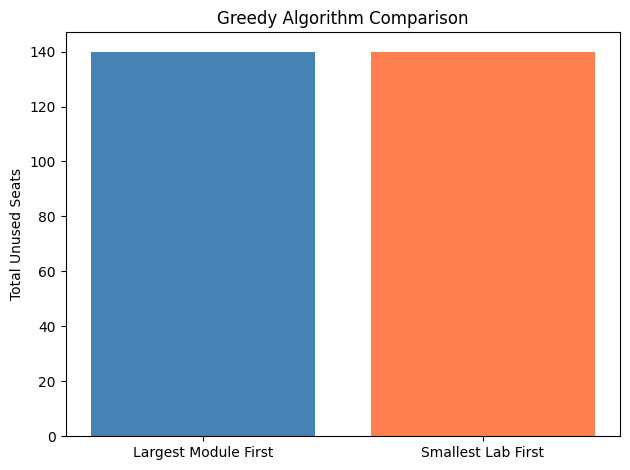

In [ ]:
labels = ['Largest Module First', 'Smallest Lab First']
totals = [df_greedy_1['Unused Seats'].sum(), df_greedy_2['Unused Seats'].sum()]

fig, ax = plt.subplots()
ax.bar(labels, totals, color=['steelblue', 'coral'])
ax.set_ylabel('Total Unused Seats')
ax.set_title('Greedy Algorithm Comparison')
plt.tight_layout()
plt.show()

## Phase 3

## Hill-Climbing Local Search


In [ ]:
def hill_climb(df_assignment):
    # Build a dict so we can look up and update assignments easily
    assignment = {}
    for i in range(len(df_assignment)):
        row = df_assignment.iloc[i]
        assignment[row['Module Code']] = row['Lab ID']

    log_rows = []
    improved = True

    while improved:
        improved = False

        for i in range(len(df_modules)):
            module = df_modules.iloc[i]
            mod_code = module['Module Code']
            current_lab_id = assignment[mod_code]

            # Find the current lab row
            current_lab = df_labs[df_labs['Lab ID'] == current_lab_id].iloc[0]
            current_waste = current_lab['Capacity'] - module['Students']

            # Try every other compatible lab to see if we can do better
            for j in range(len(df_labs)):
                lab = df_labs.iloc[j]

                if lab['Lab ID'] == current_lab_id:
                    continue

                software_ok = module['Software Needed'] in lab['Software']
                space_ok = module['Students'] <= lab['Capacity']

                if software_ok and space_ok:
                    new_waste = lab['Capacity'] - module['Students']

                    if new_waste < current_waste:
                        log_rows.append({
                            'Module Code': mod_code,
                            'From Lab': current_lab_id,
                            'To Lab': lab['Lab ID'],
                            'Waste Before': current_waste,
                            'Waste After': new_waste,
                            'Gain': current_waste - new_waste
                        })
                        assignment[mod_code] = lab['Lab ID']
                        improved = True
                        break

            if improved:
                break

    # Rebuild result DataFrame
    result_rows = []
    for i in range(len(df_modules)):
        module = df_modules.iloc[i]
        mod_code = module['Module Code']
        lab_id = assignment[mod_code]
        lab = df_labs[df_labs['Lab ID'] == lab_id].iloc[0]
        result_rows.append({
            'Module Code': mod_code,
            'Students': module['Students'],
            'Lab ID': lab_id,
            'Capacity': lab['Capacity'],
            'Unused Seats': lab['Capacity'] - module['Students']
        })

    return pd.DataFrame(result_rows), pd.DataFrame(log_rows)

Largest Module First


In [ ]:
df_hill_1, df_hill_1_log = hill_climb(df_greedy_1)

display(df_hill_1)

if len(df_hill_1_log) == 0:
    print("No improvements found — greedy solution is already at a local optimum.")
else:
    display(df_hill_1_log)

,Module Code,Students,Lab ID,Capacity,Unused Seats
0,M1,85,L1,100,15
1,M2,45,L1,100,55
2,M3,25,L4,30,5
3,M4,55,L2,60,5
4,M5,35,L3,40,5
5,M6,15,L4,30,15
6,M7,90,L1,100,10
7,M8,30,L3,40,10
8,M9,20,L4,30,10
9,M10,50,L2,60,10


No improvements found — greedy solution is already at a local optimum.


Smallest Lab First


In [ ]:
df_hill_2, df_hill_2_log = hill_climb(df_greedy_2)

display(df_hill_2)

if len(df_hill_2_log) == 0:
    print("No improvements found — greedy solution is already at a local optimum.")
else:
    display(df_hill_2_log)

,Module Code,Students,Lab ID,Capacity,Unused Seats
0,M1,85,L1,100,15
1,M2,45,L1,100,55
2,M3,25,L4,30,5
3,M4,55,L2,60,5
4,M5,35,L3,40,5
5,M6,15,L4,30,15
6,M7,90,L1,100,10
7,M8,30,L3,40,10
8,M9,20,L4,30,10
9,M10,50,L2,60,10


No improvements found — greedy solution is already at a local optimum.


## Swap Search


In [ ]:
def swap_search(df_assignment):
    # Build a working dict from the DataFrame
    assignment = {}
    for i in range(len(df_assignment)):
        row = df_assignment.iloc[i]
        assignment[row['Module Code']] = row['Lab ID']

    module_codes = list(assignment.keys())
    log_rows = []
    improved = True

    while improved:
        improved = False

        # Try every pair of modules and see if swapping their labs helps
        for i in range(len(module_codes)):
            for j in range(i + 1, len(module_codes)):
                mod_a = module_codes[i]
                mod_b = module_codes[j]
                lab_a = assignment[mod_a]
                lab_b = assignment[mod_b]

                if lab_a == lab_b:
                    continue

                module_a = df_modules[df_modules['Module Code'] == mod_a].iloc[0]
                module_b = df_modules[df_modules['Module Code'] == mod_b].iloc[0]
                lab_row_a = df_labs[df_labs['Lab ID'] == lab_a].iloc[0]
                lab_row_b = df_labs[df_labs['Lab ID'] == lab_b].iloc[0]

                # Check if the swap is feasible for both modules
                a_fits_b = module_a['Software Needed'] in lab_row_b['Software'] and module_a['Students'] <= lab_row_b['Capacity']
                b_fits_a = module_b['Software Needed'] in lab_row_a['Software'] and module_b['Students'] <= lab_row_a['Capacity']

                if a_fits_b and b_fits_a:
                    waste_before = (lab_row_a['Capacity'] - module_a['Students']) + (lab_row_b['Capacity'] - module_b['Students'])
                    waste_after  = (lab_row_b['Capacity'] - module_a['Students']) + (lab_row_a['Capacity'] - module_b['Students'])

                    if waste_after < waste_before:
                        log_rows.append({
                            'Swap': f"{mod_a} ↔ {mod_b}",
                            'Labs': f"{lab_a} ↔ {lab_b}",
                            'Waste Before': waste_before,
                            'Waste After': waste_after,
                            'Gain': waste_before - waste_after
                        })
                        assignment[mod_a] = lab_b
                        assignment[mod_b] = lab_a
                        improved = True
                        break

            if improved:
                break

    # Rebuild result DataFrame
    result_rows = []
    for i in range(len(df_modules)):
        module = df_modules.iloc[i]
        mod_code = module['Module Code']
        lab_id = assignment[mod_code]
        lab = df_labs[df_labs['Lab ID'] == lab_id].iloc[0]
        result_rows.append({
            'Module Code': mod_code,
            'Students': module['Students'],
            'Lab ID': lab_id,
            'Capacity': lab['Capacity'],
            'Unused Seats': lab['Capacity'] - module['Students']
        })

    return pd.DataFrame(result_rows), pd.DataFrame(log_rows)

Largest Module First


In [ ]:
df_swap_1, df_swap_1_log = swap_search(df_hill_1)

display(df_swap_1)

if len(df_swap_1_log) == 0:
    print("No improving swaps found — solution confirmed at local optimum.")
else:
    display(df_swap_1_log)

,Module Code,Students,Lab ID,Capacity,Unused Seats
0,M1,85,L1,100,15
1,M2,45,L1,100,55
2,M3,25,L4,30,5
3,M4,55,L2,60,5
4,M5,35,L3,40,5
5,M6,15,L4,30,15
6,M7,90,L1,100,10
7,M8,30,L3,40,10
8,M9,20,L4,30,10
9,M10,50,L2,60,10


No improving swaps found — solution confirmed at local optimum.


Smallest Lab First


In [ ]:
df_swap_2, df_swap_2_log = swap_search(df_hill_2)

display(df_swap_2)

if len(df_swap_2_log) == 0:
    print("No improving swaps found — solution confirmed at local optimum.")
else:
    display(df_swap_2_log)

,Module Code,Students,Lab ID,Capacity,Unused Seats
0,M1,85,L1,100,15
1,M2,45,L1,100,55
2,M3,25,L4,30,5
3,M4,55,L2,60,5
4,M5,35,L3,40,5
5,M6,15,L4,30,15
6,M7,90,L1,100,10
7,M8,30,L3,40,10
8,M9,20,L4,30,10
9,M10,50,L2,60,10


No improving swaps found — solution confirmed at local optimum.


## Comparison Across All Stages


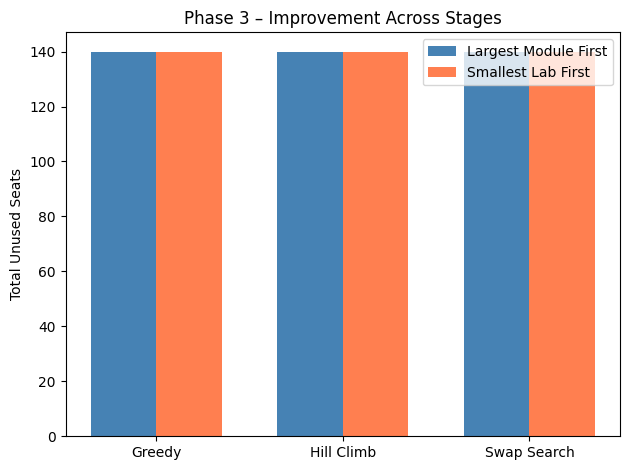

In [ ]:
import numpy as np

stages = ['Greedy', 'Hill Climb', 'Swap Search']
totals_g1 = [
    df_greedy_1['Unused Seats'].sum(),
    df_hill_1['Unused Seats'].sum(),
    df_swap_1['Unused Seats'].sum()
]
totals_g2 = [
    df_greedy_2['Unused Seats'].sum(),
    df_hill_2['Unused Seats'].sum(),
    df_swap_2['Unused Seats'].sum()
]

x = np.arange(len(stages))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width / 2, totals_g1, width, label='Largest Module First', color='steelblue')
ax.bar(x + width / 2, totals_g2, width, label='Smallest Lab First', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel('Total Unused Seats')
ax.set_title('Phase 3 – Improvement Across Stages')
ax.legend()
plt.tight_layout()
plt.show()